In [1]:
using SymPy, DifferentialEquations, LinearAlgebra, Plots, Latexify
# Latexify.set_default(; starred=true)

### RAP

In [2]:
struct parameters
    Ω::Float64     
    V_nn::Float64     
 end

In [3]:
Δ0 = 100
δ = 0.1
function (p::parameters)(t)
    global Δ0 = Δ0
    global δ =  δ
    return (p.Ω,p.V_nn,Δ0-δ*t)
end

p = parameters(1.0, Δ0/2)

parameters(1.0, 50.0)

In [4]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
ρ0 = kron(g,g) * kron(g,g)'

t_vals = 0.0 :1: 2*(Δ0+p(0)[2])/δ # Define time range
E = []
Delta = []

for t in t_vals
    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    #parameters
    Ω, V_nn, Δ_t = p(t)

    #Hamiltonian
    H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) - V_nn .* kron(n,n)
    eigenvals = eigvals(H,sortby=nothing)
    print(eigenvals[2])
    push!(E, eigenvals)
    push!(Delta, Δ_t)
end

-0.002499937503124805-0.002502439817767352-0.0025049471466913054-0.002507459504983259-0.0025099769077903855-0.0025124993703207455-0.0025150269078435894-0.0025175595356896705-0.0025200972692515475-0.0025226401239839043-0.002525188115403857-0.002527741259091275-0.0025302995706890947-0.0025328630659036413-0.0025354317605049475-0.00253800567032708-0.002540584811268463-0.002543169199292205-0.0025457588504264306-0.002548353780764608-0.0025509540064658867-0.0025535595437554287-0.00255617040892475-0.0025587866183320557-0.0025614081884025863-0.0025640351356289565-0.002566667476571506-0.0025693052278586443-0.0025719484061872007-0.0025745970283227787-0.0025772511111001066-0.0025799106714234003-0.002582575726266716-0.0025852462926743147-0.002587922387761024-0.0025906040287126055-0.0025932912327861195-0.0025959840173102994-0.0025986823996859204-0.002601386397386176-0.002604096027957054-0.0026068113090177178-0.0026095322582608883-0.0026122588934532243-0.0026149912324357144-0.002617729293124062-0.002

In [5]:
E[1]

4-element Vector{Float64}:
  -0.004999500099975008
  -0.002499937503124805
  50.00499950009997
 100.00249993750312

In [6]:
#2x2 Matrices
σ_x = [0 1; 1 0]
n = [0 0; 0 1]
I = [1 0; 0 1]
#parameters
Ω, V_nn, Δ_t = Sym("Ω V_nn Δ_t")

#Hamiltonian
H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) - V_nn .* kron(n,n)
eigenvals = eigvals(H)
latexify(H)

L"\begin{equation}
\left[
\begin{array}{cccc}
0 & \frac{\Omega}{2} & 0 & 0 \\
\frac{\Omega}{2} & \Delta_{t} & 0 & 0 \\
0 & 0 & 0 & \frac{\Omega}{2} \\
0 & 0 & \frac{\Omega}{2} &  - V_{nn} + \Delta_{t} \\
\end{array}
\right]
\end{equation}
"

In [7]:
eigenvects = eigvecs(H)
eigenvects

4×4 Matrix{Sym{PyCall.PyObject}}:
 -2*Δ_t/Ω + 2*(Δ_t/2 - sqrt(Δ_t^2 + Ω^2)/2)/Ω  …                                                                                       0
                                            1                                                                                          0
                                            0     (2*V_nn - 2*Δ_t)/Ω + 2*(-V_nn/2 + Δ_t/2 + sqrt(V_nn^2 - 2*V_nn*Δ_t + Δ_t^2 + Ω^2)/2)/Ω
                                            0                                                                                          1

In [8]:
eigenvals

4-element Vector{Sym{PyCall.PyObject}}:
                                 Δ_t/2 - sqrt(Δ_t^2 + Ω^2)/2
                                 Δ_t/2 + sqrt(Δ_t^2 + Ω^2)/2
 -V_nn/2 + Δ_t/2 - sqrt(V_nn^2 - 2*V_nn*Δ_t + Δ_t^2 + Ω^2)/2
 -V_nn/2 + Δ_t/2 + sqrt(V_nn^2 - 2*V_nn*Δ_t + Δ_t^2 + Ω^2)/2

In [9]:
E1 = [subarray[1] for subarray in E];
E2 = [subarray[2] for subarray in E];
E3 = [subarray[3] for subarray in E]
E4 = [subarray[4] for subarray in E];

In [10]:
p(1000)

(1.0, 50.0, 0.0)

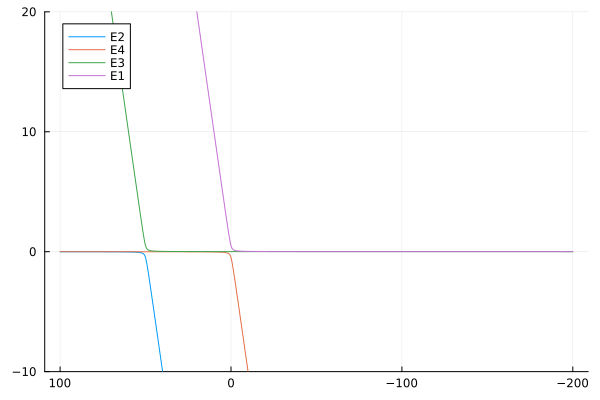

In [17]:
plot(Delta, E1, xflip=:true, label = "E2")
plot!(Delta, E2,xflip=:true,  label = "E4")
plot!(Delta, E3,xflip=:true,  label = "E3")
plot!(Delta, E4,ylim=[-10,20],xflip=:true,  label = "E1")

In [12]:
# # Basis states
# r = [0; 1]  # Assume |1>
# g = [1; 0]  # Assume |0>

# #Initial state
# ρ0 = complex(kron(r,g) * kron(r,g)')

# function rydberg_system(dρ,ρ,p,t)

#     #2x2 Matrices
#     σ_x = [0 1; 1 0]
#     n = [0 0; 0 1]

#     #parameters
#     Ω, V_nn, Δ_t = p(t)
    
#     #Hamiltonian
#     H = Ω/2 .* kron(I,σ_x) + Δ_t .* kron(I,n) + V_nn .* kron(n,n)

#     dρ .= -1im .* (H*ρ - ρ*H)
# end

In [13]:
# p = parameters(1.0)

# tspan = (0.0,-2*(Δ0+p(0)[2])/δ)
# eqn = ODEProblem(rydberg_system, ρ0, tspan, p)
# sol = solve(eqn, Rodas5(autodiff=false),saveat=0.01, progress=true);